# Linear Regression on Power Plant Output

Predicts the net hourly electrical output of a combined cycle power plant from four ambient measurements, then works through the specification questions that follow: outliers, nonlinearity, interactions, and whether a parametric model is needed at all. KNN on normalized features gives the lowest test MSE at 14.29, against 21.24 for the four-predictor OLS baseline.

**Data:** Combined Cycle Power Plant; 9,568 hourly observations, 4 features, 1 target; UCI Machine Learning Repository
https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant

## Models
| Model | Section | What it does |
|---|---|---|
| Simple OLS, one per predictor | Simple regression | Four univariate fits; outliers by studentized residual above 2 |
| Multiple OLS | Multiple regression | All four predictors; coefficient significance |
| Cubic polynomial OLS | Polynomial terms | Linear, squared and cubed terms per predictor, testing nonlinear association |
| Full interaction OLS | Pairwise interactions | All four predictors plus six pairwise interaction terms |
| OLS with backward elimination | Pairwise interactions | Interaction and quadratic terms; predictors dropped at p above 0.05 on a 70/30 split |
| KNN regression, raw features | KNN regression | k from 1 to 100 |
| KNN regression, normalized features | KNN regression | Same sweep on min-max scaled inputs |

## Contents
| Section | What it covers |
|---|---|
| Data and summary statistics | Pairwise scatterplots plus mean, median, range, quartiles and IQR per variable |
| Simple regression | One OLS fit per predictor, with outliers flagged by studentized residual |
| Multiple regression | All four predictors in one model, with coefficient significance |
| Coefficient comparison | Univariate against multiple regression coefficients, plotted per predictor |
| Polynomial terms | Cubic fit per predictor to test for nonlinear association |
| Pairwise interactions | Full interaction model, then backward elimination on p-values |
| KNN regression | Euclidean KNN over k = 1 to 100, on raw and on min-max normalized features |
| Model comparison | Test MSE across the OLS variants and both KNN fits |

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data
Download the Combined Cycle Power Plant data1 from: https://archive.ics.uci.edu/ml/datasets/Combined+Cycle+Power+Plant

| Variable Name | Description | Data Type | Role | Units |
| :--- | :--- | :--- | :--- |:--- |
| **T** | Temperature (hourly average) | Continuous | Feature  | C |
| **AP** | Ambient Pressure (hourly average) | Continuous | Feature  | milibar |
| **RH** | Relative Humidity (hourly average) | Continuous | Feature  | % |
| **V** | Exhaust Vacuum (hourly average) | Continuous | Feature  | cm Hg |
| **EP** | Net hourly electrical energy output | Continuous | Target  | MW|

Package imports

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler



Get the Cycle Power Plant Data Set

In [58]:
df = pd.read_excel("data/Folds5x2_pp.xlsx")
df = df.rename(columns = {'AT':'T', 'PE':'EP'})
df


,T,V,AP,RH,EP
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


### (b) Exploring the data

#### i. rows and columns

In [59]:
row_count, col_count = df.shape
print(f"Row count: {row_count}")
print(f"Column count: {col_count}")
print("Each row represents a single observation when the power plant was set to work with full load, and consist of hourly average ambient variables for each column feature Temperature (T), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) and target column net hourly electrical energy output (EP) of the plant.")


Row count: 9568
Column count: 5
Each row represents a single observation when the power plant was set to work with full load, and consist of hourly average ambient variables for each column feature Temperature (T), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) and target column net hourly electrical energy output (EP) of the plant.


#### ii. pairwise scatterplots of all the varianbles

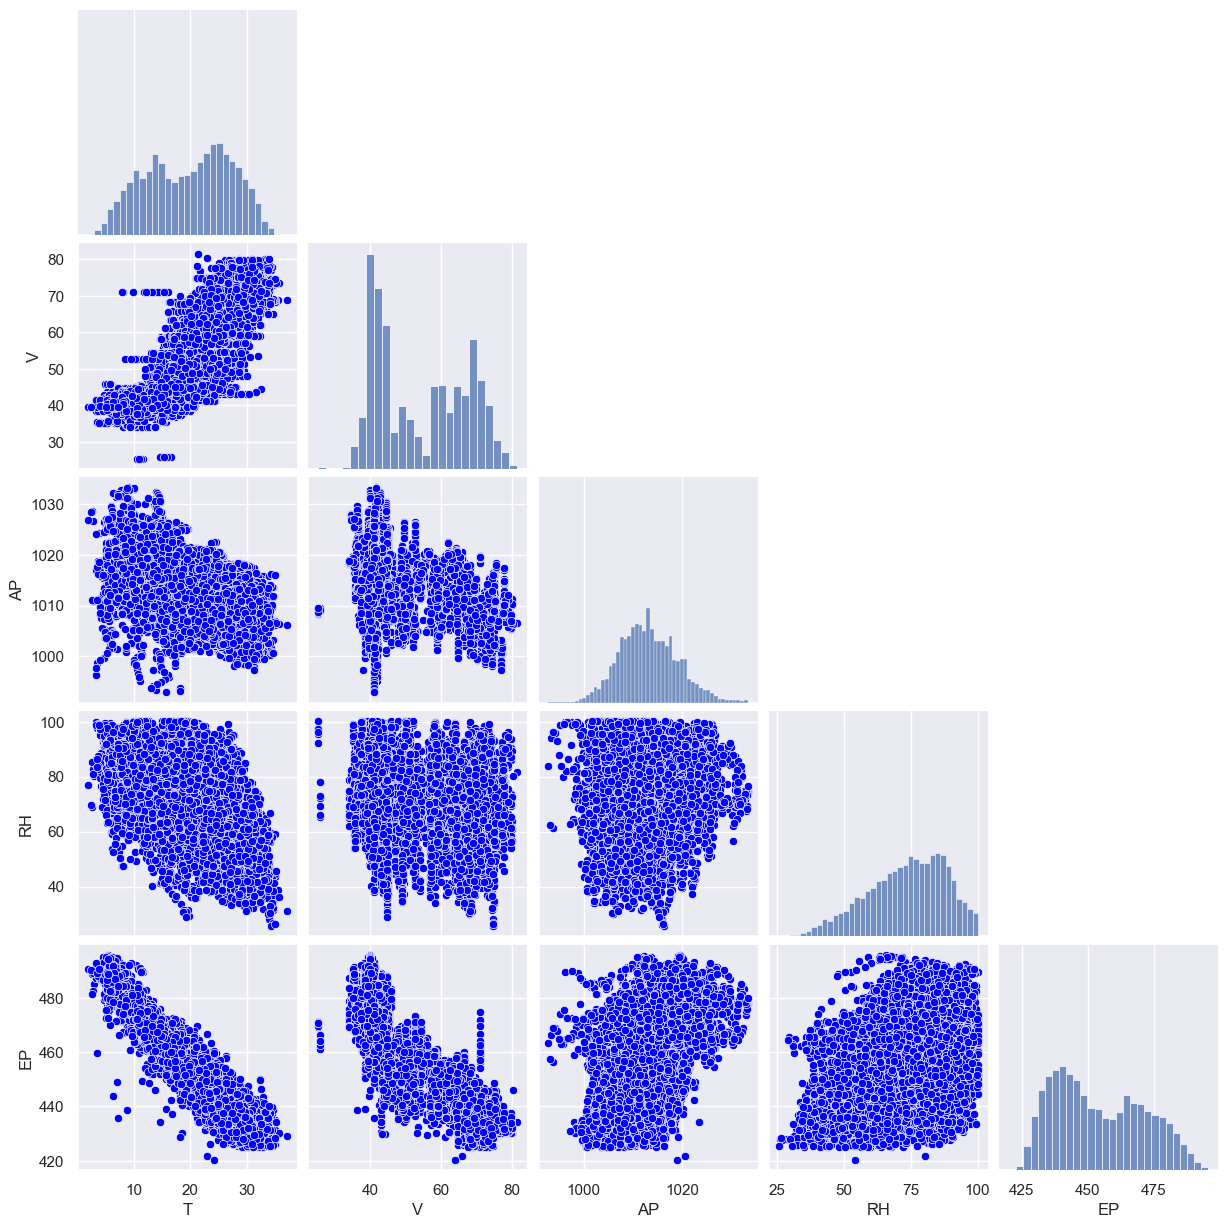

In [60]:
sns.set()
sns.pairplot(data=df, plot_kws= {"color":"blue"}, corner=True )
plt.show()

**Observations from Scatter Plots**
- **T vs EP**: strong sign of negative correlation and linera relationship
- **V vs EP**: negative correlation, and can assume some linera relationship (however, quadratic model should also be tested )
- **T vs V**: positive correlation between these independent variables, which is a sign of multicollinearity

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [61]:
sum_stats = df.describe()
sum_stats = sum_stats.transpose().rename(columns = {'mean':'Mean','25%':'Q1', '50%':'Median', '75%':'Q3'})
sum_stats['IQR'] = sum_stats['Q3'] - sum_stats['Q1']
sum_stats['Range'] = sum_stats['max'] - sum_stats['min']
sum_stats = sum_stats.drop(columns = ['count', 'std', 'max', 'min'])
sum_stats

,Mean,Q1,Median,Q3,IQR,Range
T,19.651231,13.5100,20.345,25.72,12.2100,35.30
V,54.305804,41.7400,52.080,66.54,24.8000,56.20
AP,1013.259078,1009.1000,1012.940,1017.26,8.1600,40.41
RH,73.308978,63.3275,74.975,84.83,21.5025,74.60
EP,454.365009,439.7500,451.550,468.43,28.6800,75.50


### (c) Simple Linear Regression and Outlier Detection

In [62]:
def liner_reg(feature):
    Y = df['EP']
    X = df[feature]
    X = sm.add_constant(X)
    reg = sm.OLS(Y, X).fit()
    print(f"OLS: EP vs {feature}")
    print(f"R-squared: {reg.rsquared:.4f}")
    print(reg.summary().tables[1])
    return reg

def get_outliers(reg):
    std_resid = reg.get_influence().resid_studentized_internal
    outliers = abs(std_resid) > 2
    return outliers

def plot_reg_with_outliers(feature, reg, outliers):
    print(f"Number of Outliers Detected: {outliers.sum()} (Studentized Residuals > 2)")
    X = sm.add_constant(df[feature])
    y_pred = reg.predict(X)
    df_outliers = df[outliers]
    df_normal = df[outliers == False]
    plt.scatter(df_normal[feature], df_normal['EP'], facecolors='blue', alpha=0.5, label='Normal Data point')
    plt.scatter(df_outliers[feature], df_outliers['EP'],color='purple', label='Outliers',alpha=0.5,)
    plt.plot(df[feature], y_pred, linewidth=2, color='red', label='Regression Line')
    plt.title(f"Regression: EP vs {feature}")
    plt.xlabel(feature)
    plt.ylabel('EP')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# For part e
univariate_coeffs = {}


OLS: EP vs T
R-squared: 0.8989
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      0.000     496.727     497.341
T             -2.1713      0.007   -291.715      0.000      -2.186      -2.157
Number of Outliers Detected: 405 (Studentized Residuals > 2)


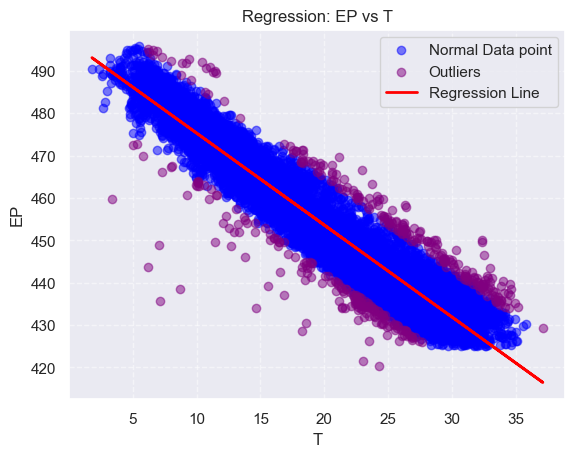

OLS: EP vs V
R-squared: 0.7565
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.8015      0.378   1370.218      0.000     517.061     518.542
V             -1.1681      0.007   -172.402      0.000      -1.181      -1.155
Number of Outliers Detected: 506 (Studentized Residuals > 2)


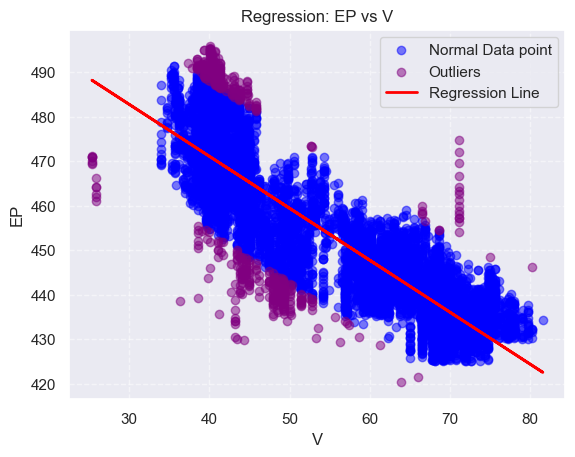

OLS: EP vs AP
R-squared: 0.2688
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1055.2610     25.459    -41.449      0.000   -1105.167   -1005.355
AP             1.4899      0.025     59.296      0.000       1.441       1.539
Number of Outliers Detected: 368 (Studentized Residuals > 2)


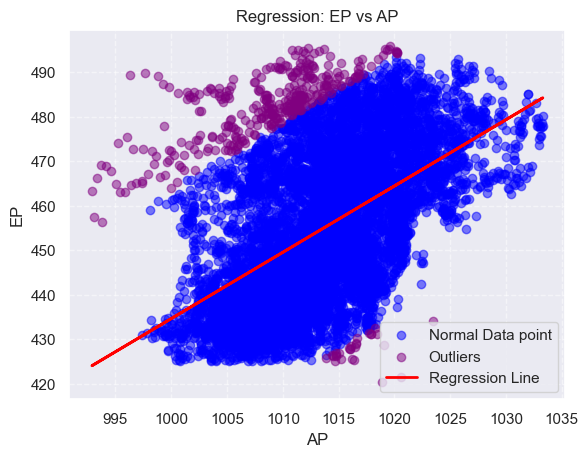

OLS: EP vs RH
R-squared: 0.1519
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        420.9618      0.823    511.676      0.000     419.349     422.574
RH             0.4557      0.011     41.399      0.000       0.434       0.477
Number of Outliers Detected: 194 (Studentized Residuals > 2)


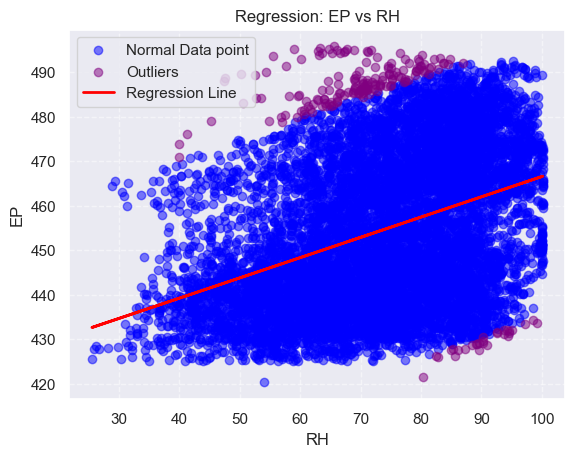

In [63]:

for feature in ['T', 'V', 'AP', 'RH']:
    reg = liner_reg(feature)
    outliers = get_outliers(reg)
    plot_reg_with_outliers(feature, reg, outliers)

    # For part e
    coef = reg.params[feature]
    univariate_coeffs[feature] = coef



#### Results:
- **Significance:**  Predictors (T, V, AP, RH) have a statistically significant association with the response EP ($p \text{-value} < 0.05$).
- **Relationship:** Assumption that T and V are inversely related to EP was confirmed by the negative signs of their coefficients in the OLS results. Additionally,
- **Outliers:** Using Studentized Residuals (threshold $>2$), we identified outliers in all four models. We detected more outliers in T and V because the OlS fits data better and model is more precise (lower variance). Due to this strict (low) standard error causes even minor deviations to have high penalty and be flagged as statistically significant outliers.


### (d) Multiple Regression

In [64]:
Y = df['EP']
X = df[['T','V','AP','RH']]
X = sm.add_constant(X)
reg_all_features = sm.OLS(Y, X).fit()
print(reg_all_features.summary())
print(reg_all_features.params)



                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:13:39   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

All predictors (T, V, AP, RH) are statistically significant ($p \text{-value} < 0.05$), hence we can reject null hypothesis ($H_0 : \beta_j = 0$) for all of them.

### (e) 1c Compare to 1d

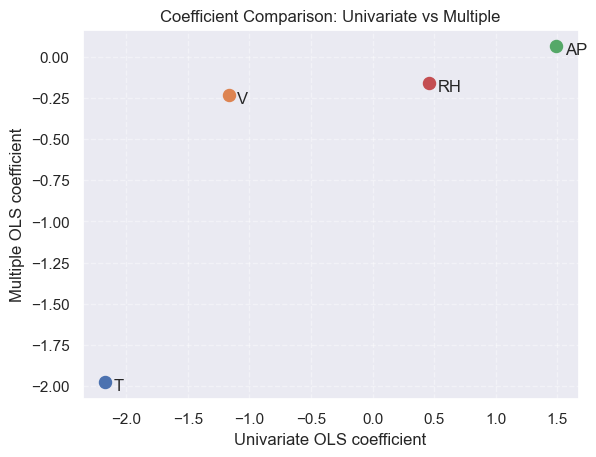

,Univariate Coefficient,Multivariate Coefficient
T,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


In [65]:
multivariate_coeffs = {
    'T': reg_all_features.params['T'],
    'V': reg_all_features.params['V'],
    'AP': reg_all_features.params['AP'],
    'RH':reg_all_features.params['RH']}
for feature in multivariate_coeffs:
    x = univariate_coeffs[feature]
    y = multivariate_coeffs[feature]
    plt.scatter(x, y, s =75)
    plt.text(x+0.07, y-.05, feature, fontsize=12)

plt.title("Coefficient Comparison: Univariate vs Multiple")
plt.xlabel('Univariate OLS coefficient')
plt.ylabel('Multiple OLS coefficient')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

comp_table = pd.DataFrame({
    'Univariate Coefficient': univariate_coeffs,
    'Multivariate Coefficient': multivariate_coeffs
})
comp_table


### (f) Nonlinear Association,
 $ EP = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon$

In [66]:
def nonliner_reg(feature):
    Y = df['EP']
    X = df[feature]
    X_pol = pd.DataFrame({feature: X, f'{feature}^2':X**2, f'{feature}^3':X**3})
    X_pol = sm.add_constant(X_pol)
    model = sm.OLS(Y, X_pol).fit()
    print(f"OLS: EP vs {X_pol.columns[1:].tolist()}")
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"F-statistic: {model.fvalue:.4f}     with Prob (F-statistic):  { model.f_pvalue} ")
    print(model.summary().tables[1], "\n")
    return model

for feature in ['T', 'V', 'AP', 'RH']:
    nonliner_reg(feature)

OLS: EP vs ['T', 'T^2', 'T^3']
R-squared: 0.9119
F-statistic: 32991.0324     with Prob (F-statistic):  0.0 
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.7281      0.673    732.248      0.000     491.409     494.047
T             -0.6103      0.124     -4.941      0.000      -0.852      -0.368
T^2           -0.1251      0.007    -18.199      0.000      -0.139      -0.112
T^3            0.0027      0.000     22.594      0.000       0.002       0.003

OLS: EP vs ['V', 'V^2', 'V^3']
R-squared: 0.7750
F-statistic: 10982.2730     with Prob (F-statistic):  0.0 
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        554.1468      9.151     60.557      0.000     536.209     572.084
V             -2.1444      0.509     -4.214      0.000      -3.142      

#### Results: ####
- **Overall Model Significance:** F-stat for every model is significant ($p \approx 0.0$), indicating that at least one $ \beta_i \neq 0 $
- **T, AP and RH:** There is nonlinear association  for three predictors (T, RH, AP), since quadratic ($X^2$) and cubic ($X^3$) terms are significant  ($p \text{-value} < 0.05$), hence we can reject null hypothesis ($H_0 : \beta_j = 0$) for all of polynomial terms coefficients.
- **V:** The quadratic term ($V^2$) is not significant ($p = 0.768$), while the cubic term ($V^3$) is significant ($p = 0.014< 0.05$). Hence there are mediocre evidence of non-linearity.

### (g) Interactions of Predictors

In [67]:
Y = df['EP']
X_inter = df[['T', 'V', 'AP', 'RH']].copy()

# create interaction terms
X_inter['T*V']  = df['T'] * df['V']
X_inter['T*AP'] = df['T'] * df['AP']
X_inter['T*RH'] = df['T'] * df['RH']
X_inter['V*AP'] = df['V'] * df['AP']
X_inter['V*RH'] = df['V'] * df['RH']
X_inter['AP*RH']= df['AP'] * df['RH']

X_inter = sm.add_constant(X_inter)
model_inter = sm.OLS(Y, X_inter).fit()
print(model_inter.summary())

                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:13:39   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

#### Results: ####
- **Significant interaction terms ( $ p \text{-value} < 0.05$ ):** are $T \times V$, $T \times RH$, $V \times AP$, $AP \times RH$ hence there is evidence of four pairwise interaction terms being relevant for model.
- **Not significant interaction terms ( $ p \text{-value} > 0.05$ ):** are $T \times AP$, $V \times RH$
- **Negative effect on significance of features:** after adding interaction terms T became not significant ( $ p \text{-value} = 0.067 > 0.005$ ) and for both AP and RH $ p\text{-value}$ values increased reducing there significance

### (h) Improvement

In [68]:
y = df['EP']
X_all = X_inter.copy() #from part g already inlcudes constant
X_all['T^2'] = df['T']**2
X_all['V^2'] = df['V']**2
X_all['AP^2'] = df['AP']**2
X_all['RH^2'] = df['RH']**2

base_features = ['const', 'T', 'V', 'AP', 'RH'] # list of base model feature names
all_features = list(X_all.columns)  # list of all feature names

X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.3, random_state=42)

def get_model_stats(feature_list):
    model = sm.OLS(y_train, X_train[feature_list]).fit()

    train_pred = model.predict(X_train[feature_list])
    test_pred = model.predict(X_test[feature_list])
    mse_train = mean_squared_error(y_train, train_pred)
    mse_test = mean_squared_error(y_test, test_pred)

    print(f"R-squared: {model.rsquared:.4f}   and   Adj. R-squared:  {model.rsquared_adj:.4f}")
    print(f"Train MSE: {mse_train:.4f}")
    print(f"Test MSE: {mse_test:.4f}")
    return model


print("Backward Elimination")
while True:
    model_inspect = get_model_stats(all_features)
    p_values = model_inspect.pvalues.drop('const', errors='ignore')
    max_p = p_values.max()
    feature_drop = p_values.idxmax()
    if max_p > 0.05:
        print(f"Removing '{feature_drop}' (p-value: {max_p:.4f})\n")
        all_features.remove(feature_drop)
    else:
        break


print(f"\nFinal Model with features: {all_features[1:]}")
print(get_model_stats(all_features).summary().tables[1])
print(f"\nBase Model: {base_features[1:]}")
print(get_model_stats(base_features).summary().tables[1])



Backward Elimination
R-squared: 0.9384   and   Adj. R-squared:  0.9383
Train MSE: 17.8878
Test MSE: 18.6473
Removing 'V*RH' (p-value: 0.8674)

R-squared: 0.9384   and   Adj. R-squared:  0.9383
Train MSE: 17.8879
Test MSE: 18.6450
Removing 'V^2' (p-value: 0.6077)

R-squared: 0.9384   and   Adj. R-squared:  0.9383
Train MSE: 17.8886
Test MSE: 18.6521
Removing 'V*AP' (p-value: 0.3578)

R-squared: 0.9384   and   Adj. R-squared:  0.9383
Train MSE: 17.8908
Test MSE: 18.6600

Final Model with features: ['T', 'V', 'AP', 'RH', 'T*V', 'T*AP', 'T*RH', 'AP*RH', 'T^2', 'AP^2', 'RH^2']
R-squared: 0.9384   and   Adj. R-squared:  0.9383
Train MSE: 17.8908
Test MSE: 18.6600
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7568.5210   1420.561     -5.328      0.000   -1.04e+04   -4783.768
T             -9.6925      2.290     -4.232      0.000     -14.182      -5.203
V             -0.4

 **Modified Model** ['T', 'V', 'AP', 'RH', 'T*V', 'T*AP', 'T*RH', 'AP*RH', 'T^2', 'AP^2', 'RH^2'] acheved lower MSE values than **Base Model** ['T', 'V', 'AP', 'RH'] for both train and test datasets.  Additionally, the model's explanatory power improved after the inclusion of nonlinear and interaction terms, as evidenced by the increase in both $R^2$ and Adjusted $R^2$ values.

### (i) KNN

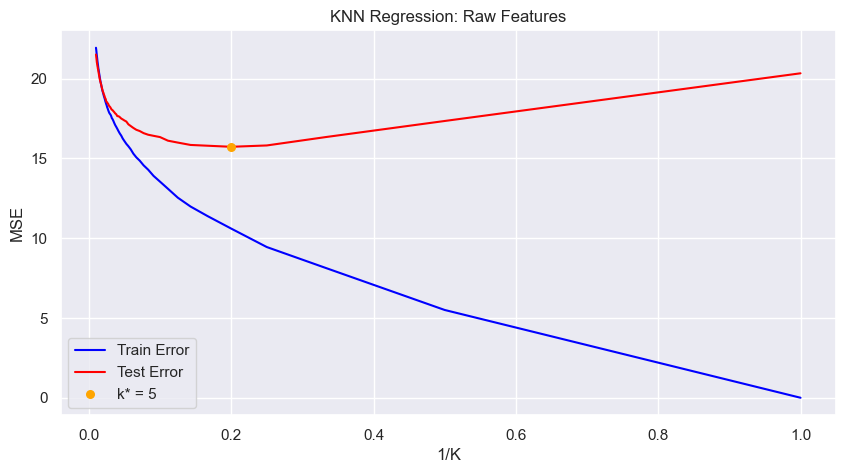

For Raw Features: Best fit K = 5 with Test MSE = 15.7268


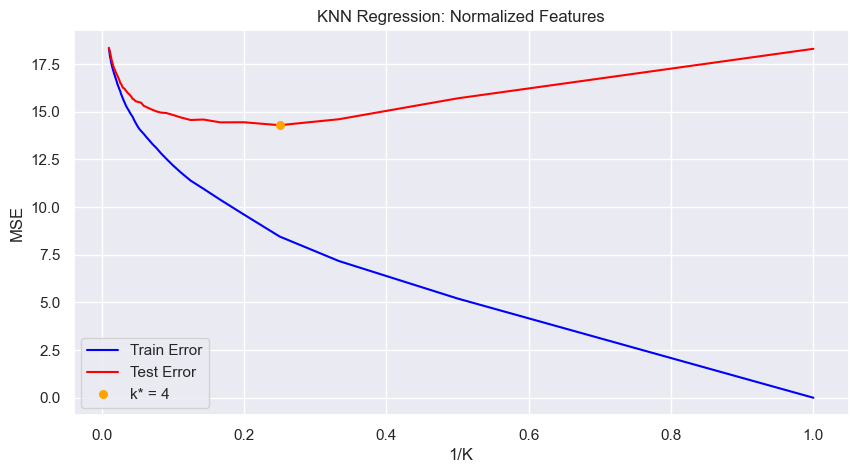

For Normalized Features: Best fit K = 4 with Test MSE = 14.2913


In [69]:
y = df['EP']
X = df[['T', 'V', 'AP', 'RH']]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train_raw)
X_test_norm = scaler.transform(X_test_raw)


def knn_reg(X_train, X_test, type):
    k_values = np.arange(1,101,1)
    one_over_k_values = 1/k_values
    train_err = []
    test_err = []
    for k in k_values:
        knn = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
        knn.fit(X_train, y_train)
        y_train_pred = knn.predict(X_train)
        y_test_pred = knn.predict(X_test)
        train_err.append(mean_squared_error(y_train, y_train_pred))
        test_err.append(mean_squared_error(y_test, y_test_pred))

    k_star = k_values[np.argmin(test_err)]
    k_star_mse = min(test_err)

    plt.figure(figsize=(10, 5))
    plt.plot(one_over_k_values, train_err, label='Train Error', color='blue')
    plt.plot(one_over_k_values, test_err, label='Test Error', color='red')
    plt.scatter(1/k_star, k_star_mse, color='orange', s=30, label=f'k* = {k_star}',zorder=5)
    plt.xlabel("1/K")
    plt.ylabel("MSE")
    plt.title(f'KNN Regression: {type}')
    plt.legend()
    plt.show()
    return k_star, k_star_mse

k_raw_star, k_raw_star_mse = knn_reg(X_train_raw, X_test_raw, "Raw Features")
print(f"For Raw Features: Best fit K = {k_raw_star} with Test MSE = {k_raw_star_mse:.4f}")
k_norm_star, k_norm_star_mse = knn_reg(X_train_norm, X_test_norm, "Normalized Features")
print(f"For Normalized Features: Best fit K = {k_norm_star} with Test MSE = {k_norm_star_mse:.4f}")


### (j ) Compare KNN and Linear


| Model                          | Key Features / Parameters     | Test MSE    |
|:-------------------------------|:------------------------------|:------------|
| **OLS: Baseline**              | T, V, AP, RH                  | **21.2399** |
| **OLS: All Terms**             | All Interactions & Quadratics | **18.6473** |
| **OLS: Final Modified**        | 11 Significant Features       | **18.6600** |
| **KNN Regression: Raw**        | $k = 5$, Original Scales      | **15.7268** |
| **KNN Regression: Normalized** | $k = 4$, Scaled Features      | **14.2913** |

KNN models outperformed on MSE metric, suggesting non-parametric approach suits better this data than linear regression by capturing local non-linear patterns. Especially Normalizing features for KNN resulted in lowest test error (14.2913).
Even though OLS models are doing worse in predicting target variable $EP$, they carry more explanatory power about relationships between specific features and $EP$; this allows to make assumptions about quantitative impact of a single predictor on target value.



### References

- https://www.statsmodels.org/stable/examples/notebooks/generated/ols.html

- https://www.statsmodels.org/dev/generated/statsmodels.stats.outliers_influence.OLSInfluence.html

- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html